# Modelo Preditivo - Risco de Defasagem

Objetivo: prever, a partir dos indicadores do aluno no ano t, se o aluno estará em defasagem em relação ao nível ideal no ano t+1.

Define-se aluno em defasagem quando `Defasagem < 0` (nível atual abaixo do ideal).

Etapas: feature engineering, split treino/teste, comparação de modelos, avaliação, persistência do melhor modelo.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from etl import construir_long
from modelo import (
    montar_pares_temporais, treinar_e_avaliar, salvar_modelo,
    NUM_FEATURES, CAT_FEATURES,
)
from sklearn.metrics import (
    roc_curve, roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve
)

sns.set_theme(style='whitegrid')

## 1. Construção do dataset

A função `montar_pares_temporais` junta cada aluno em pares (ano t, ano t+1). As features vêm do ano t e o alvo do ano t+1.

In [2]:
df_long = construir_long()
pares = montar_pares_temporais(df_long)
print('linhas:', len(pares))
print('proporcao positiva:', pares['alvo'].mean().round(3))
pares.head()

linhas: 1248
proporcao positiva: 0.534


,RA,Ano,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Idade,Tempo_PM,Genero,Pedra,alvo
0,RA-1000,2023,7.9162,8.5,9.4,3.77,6.250,7.0,8.92,10.0,8.0,0.0,Feminino,Ametista,0
1,RA-1001,2023,8.1162,9.0,9.1,7.52,7.500,7.8,9.17,5.0,9.0,0.0,Feminino,Topázio,1
2,RA-1002,2023,7.9012,9.0,9.7,7.52,6.250,7.0,8.92,5.0,9.0,0.0,Feminino,Ametista,1
3,RA-1003,2023,7.6522,9.0,8.5,7.52,7.500,4.0,8.75,10.0,8.0,0.0,Masculino,Ametista,1
4,RA-1004,2023,8.3137,9.0,9.6,7.52,6.875,7.9,7.42,10.0,8.0,0.0,Feminino,Topázio,1


## 2. Feature engineering

Numéricas: `INDE, IAA, IEG, IPS, IPP, IDA, IPV, IAN, Idade, Tempo_PM`.
Categóricas: `Genero, Pedra`.

O pipeline cuida de imputação, padronização e one-hot encoding.

In [3]:
print('Numericas:', NUM_FEATURES)
print('Categoricas:', CAT_FEATURES)
pares[NUM_FEATURES].describe().round(2)

Numericas: ['INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'Idade', 'Tempo_PM']
Categoricas: ['Genero', 'Pedra']


,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Idade,Tempo_PM
count,1248.00,1248.00,1248.00,1248.00,678.00,1248.00,1248.00,1248.00,976.00,1248.00
mean,7.36,7.67,8.62,5.94,7.61,6.67,7.80,6.88,11.53,1.57
std,0.87,2.98,1.18,1.90,0.98,1.69,1.01,2.47,2.46,1.81
min,3.70,0.00,2.00,2.50,4.38,1.00,3.32,2.50,7.00,0.00
25%,6.81,7.80,8.10,5.00,7.11,5.70,7.22,5.00,10.00,0.00
50%,7.45,8.80,8.90,6.90,7.71,6.90,7.83,5.00,11.00,1.00
75%,7.99,9.50,9.50,7.50,8.28,7.90,8.44,10.00,13.00,3.00
max,9.44,10.00,10.00,9.40,9.79,10.00,10.01,10.00,19.00,7.00


## 3. Treino e avaliação

Comparando logística, random forest e gradient boosting. Hold-out estratificado de 25%.

In [4]:
resultados, melhor, splits = treinar_e_avaliar(pares)
X_tr, X_te, y_tr, y_te = splits
for nome, r in resultados.items():
    print(f'{nome}: AUC={r["auc"]:.4f}')
print('melhor modelo:', melhor)

logistica: AUC=0.8265
random_forest: AUC=0.8356
gradient_boosting: AUC=0.8446
melhor modelo: gradient_boosting


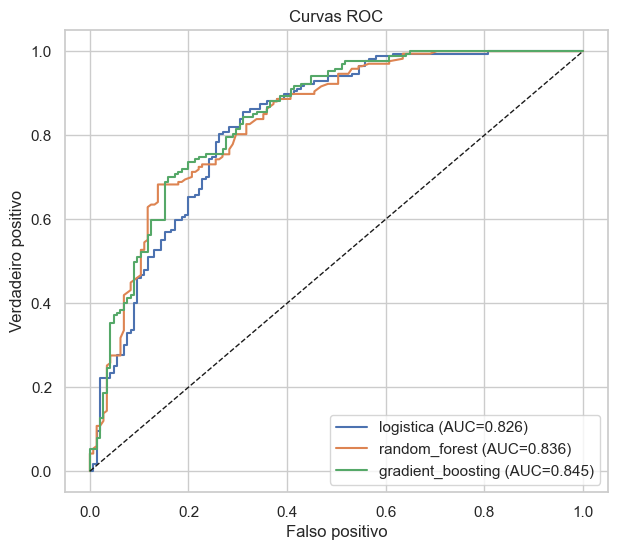

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for nome, r in resultados.items():
    proba = r['pipe'].predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, label=f'{nome} (AUC={r["auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('Falso positivo')
ax.set_ylabel('Verdadeiro positivo')
ax.set_title('Curvas ROC')
ax.legend()
plt.show()

              precision    recall  f1-score   support

   Sem risco       0.78      0.69      0.73       145
    Em risco       0.76      0.83      0.79       167

    accuracy                           0.77       312
   macro avg       0.77      0.76      0.76       312
weighted avg       0.77      0.77      0.76       312



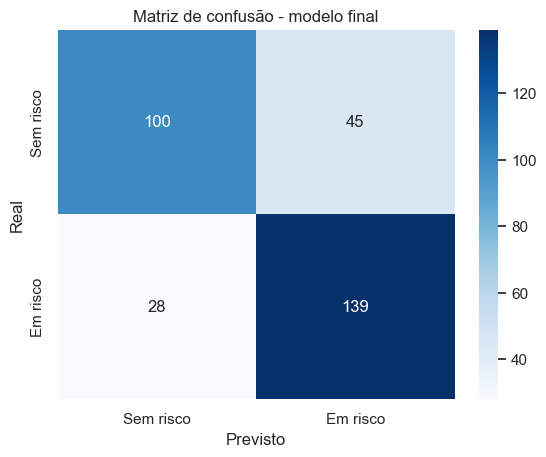

In [6]:
pipe = resultados[melhor]['pipe']
y_pred = pipe.predict(X_te)
y_proba = pipe.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred, target_names=['Sem risco', 'Em risco']))
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem risco', 'Em risco'],
            yticklabels=['Sem risco', 'Em risco'])
plt.title('Matriz de confusão - modelo final')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

## 4. Importância das variáveis

Como o melhor modelo é o `gradient_boosting`, dá pra olhar feature importances já mapeadas para os nomes pós one-hot.

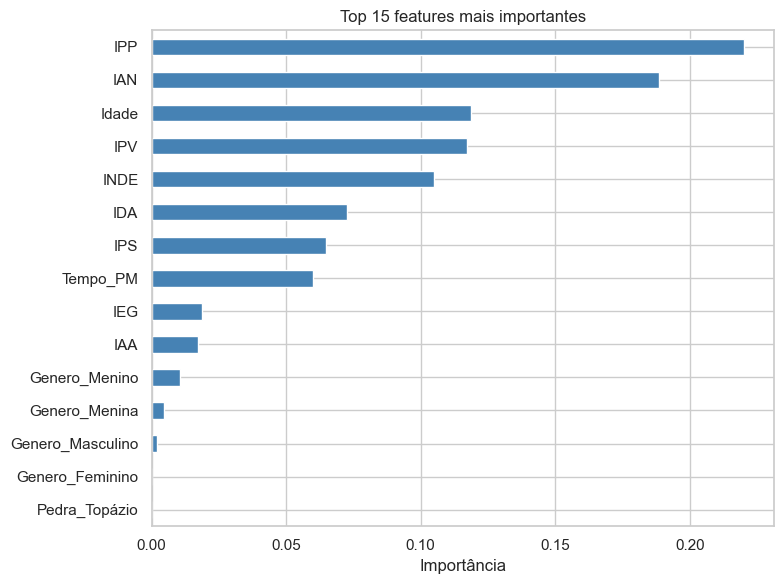

In [7]:
pre = pipe.named_steps['pre']
clf = pipe.named_steps['clf']
feat_names = NUM_FEATURES + list(
    pre.named_transformers_['cat'].named_steps['oh'].get_feature_names_out(CAT_FEATURES)
)
imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=True)
imp.tail(15).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 15 features mais importantes')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

## 5. Calibração de threshold

O threshold padrão (0,5) nem sempre é o melhor para identificar risco. Olho a curva precision-recall e escolho um corte mais sensível.

threshold otimo (F1): 0.318
precision=0.707 recall=0.940 f1=0.807


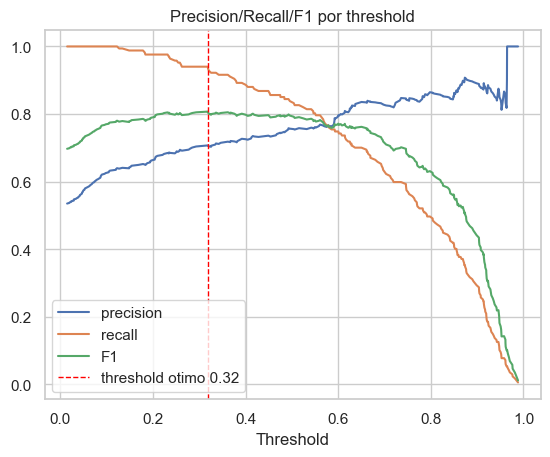

In [8]:
prec, rec, thr = precision_recall_curve(y_te, y_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1[:-1])
thr_best = thr[best_idx]
print(f'threshold otimo (F1): {thr_best:.3f}')
print(f'precision={prec[best_idx]:.3f} recall={rec[best_idx]:.3f} f1={f1[best_idx]:.3f}')

plt.plot(thr, prec[:-1], label='precision')
plt.plot(thr, rec[:-1], label='recall')
plt.plot(thr, f1[:-1], label='F1')
plt.axvline(thr_best, color='red', ls='--', lw=1, label=f'threshold otimo {thr_best:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision/Recall/F1 por threshold')
plt.show()

## 6. Persistência

Salvo o pipeline completo (preprocessador + modelo) para uso pelo app Streamlit.

In [9]:
caminho = salvar_modelo(pipe)
print('modelo salvo em:', caminho)

modelo salvo em: /Users/guscamar/Desktop/FIAP5/DATATHON/projeto/models/modelo_risco.joblib


## 7. Próximos passos

- Validação cruzada estratificada por aluno (group k-fold) para evitar vazamento entre anos.
- Adicionar variação dos indicadores entre anos como features.
- Regressão para prever o INDE futuro, complementando a classificação binária.
- Ajuste de threshold em conjunto com a equipe da Passos para equilibrar custo de falso positivo (intervenção desnecessária) e falso negativo (deixa passar aluno em risco).